In [1]:
from pathlib import Path
experimento = 'B'
path_carpeta = "../dataset/CSE-2018"
path_database = "05-01-06-prepared-dataset-no-dup-L1-all-labels.csv"
path_input = f'{path_carpeta}/{path_database}';
path_output = Path(f"dataset/{experimento}-02-dataset-balanceado.csv")
name_target = "LABEL"

In [2]:
import pandas as pd
data = pd.read_csv(str(f'{path_carpeta}/{path_database}'))
#data = data.sample(n=300000, random_state=42) # Tomar un subconjunto de prueba
x = data.drop([name_target], axis=1)
y = data[name_target]

NÚMERO DE PATRONES POR ETIQUETA ANTES DE OVERFITTING
LABEL
0     2670478
2      668461
1      576175
3      434873
4      282310
5      160604
6      117322
7       41455
14      39346
13      19462
8       10285
9        1730
10        611
11        230
12         87
Name: count, dtype: int64


<BarContainer object of 15 artists>

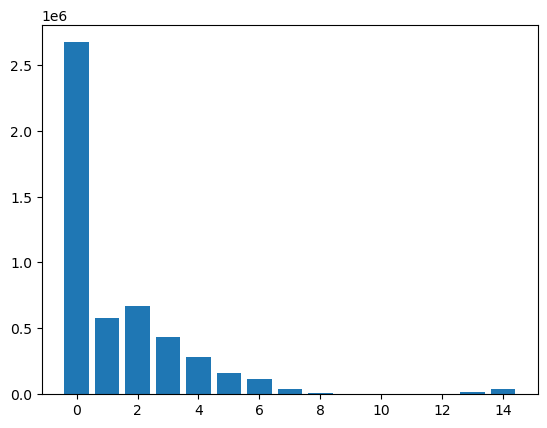

In [3]:
import matplotlib.pyplot as plt
n_values = y.value_counts()
print("NÚMERO DE PATRONES POR ETIQUETA ANTES DE OVERFITTING")
print(n_values)
plt.bar(n_values.index, n_values.values)

In [4]:
import numpy as np
import pandas as pd
from collections import Counter
from imblearn.over_sampling import SMOTE

TARGET_PER_MALIGN = 190_748
BENIGN_LABEL = 0

# Si x es numpy, lo paso a DataFrame solo para manejar índices más cómodo (opcional)
if not isinstance(x, pd.DataFrame):
    x = pd.DataFrame(x)
if not isinstance(y, pd.Series):
    y = pd.Series(y)

# 1) Separo benignos y malignos
mask_benign = (y == BENIGN_LABEL)
X_benign = x[mask_benign]
y_benign = y[mask_benign]

X_mal = x[~mask_benign]
y_mal = y[~mask_benign]

print("Distribución original malignas:", Counter(y_mal))

# 2) UNDERSAMPLING de las malignas que tengan más de TARGET_PER_MALIGN
indices_keep = []

counts = Counter(y_mal)
rng = np.random.default_rng(42)

for cls, cnt in counts.items():
    cls_indices = np.where(y_mal.values == cls)[0]
    if cnt > TARGET_PER_MALIGN:
        # elige aleatoriamente TARGET_PER_MALIGN
        keep = rng.choice(cls_indices, size=TARGET_PER_MALIGN, replace=False)
    else:
        # si ya tiene menos, de momento la dejamos tal cual
        keep = cls_indices
    indices_keep.extend(keep)

indices_keep = np.array(indices_keep)
X_mal_under = X_mal.iloc[indices_keep]
y_mal_under = y_mal.iloc[indices_keep]

print("Después de undersampling:", Counter(y_mal_under))

# 3) OVERSAMPLING (SMOTE) de las malignas que aún tengan menos de TARGET_PER_MALIGN
#    Creamos un diccionario con el tamaño objetivo por clase
sampling_dict = {
    cls: TARGET_PER_MALIGN
    for cls, cnt in Counter(y_mal_under).items()
    if cnt < TARGET_PER_MALIGN
}

print("Clases a oversamplear con SMOTE:", sampling_dict)

smote = SMOTE(sampling_strategy=sampling_dict, random_state=42)
X_mal_bal, y_mal_bal = smote.fit_resample(X_mal_under, y_mal_under)

print("Distribución final malignas:", Counter(y_mal_bal))

# 4) Volvemos a juntar benignos + malignos balanceados
X_final = pd.concat([X_benign, pd.DataFrame(X_mal_bal, index=None)], ignore_index=True)
y_final = pd.concat([y_benign.reset_index(drop=True),
                     pd.Series(y_mal_bal).reset_index(drop=True)],
                    ignore_index=True)

print("Distribución final total:", Counter(y_final))


Distribución original malignas: Counter({2: 668461, 1: 576175, 3: 434873, 4: 282310, 5: 160604, 6: 117322, 7: 41455, 14: 39346, 13: 19462, 8: 10285, 9: 1730, 10: 611, 11: 230, 12: 87})
Después de undersampling: Counter({1: 190748, 2: 190748, 3: 190748, 4: 190748, 5: 160604, 6: 117322, 7: 41455, 14: 39346, 13: 19462, 8: 10285, 9: 1730, 10: 611, 11: 230, 12: 87})
Clases a oversamplear con SMOTE: {5: 190748, 6: 190748, 7: 190748, 8: 190748, 9: 190748, 10: 190748, 11: 190748, 12: 190748, 13: 190748, 14: 190748}
Distribución final malignas: Counter({1: 190748, 2: 190748, 3: 190748, 4: 190748, 5: 190748, 6: 190748, 7: 190748, 8: 190748, 9: 190748, 10: 190748, 11: 190748, 12: 190748, 13: 190748, 14: 190748})
Distribución final total: Counter({0: 2670478, 1: 190748, 2: 190748, 3: 190748, 4: 190748, 5: 190748, 6: 190748, 7: 190748, 8: 190748, 9: 190748, 10: 190748, 11: 190748, 12: 190748, 13: 190748, 14: 190748})


NÚMERO DE PATRONES POR LABEL DESPUÉS DE ELIMINAR DUPLICADOS
LABEL
0     2670478
1      190748
2      190748
3      190748
4      190748
12     190748
9      190748
11     190407
6      190195
5      189957
7      189286
10     187945
8      185522
14     184603
13     179983
Name: count, dtype: int64


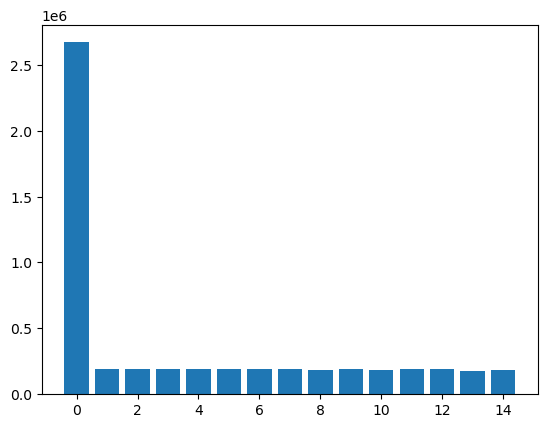

In [5]:
# Unimos x e y en un único DataFrame
df_resampleado = X_final.copy()
df_resampleado[name_target] = y_final

# QUITAR DUPLICADOS
df_resampleado = df_resampleado.drop_duplicates()
x_sin_duplicados = df_resampleado.drop([name_target], axis=1)
y_sin_duplicados = df_resampleado[name_target]
n_values = y_sin_duplicados.value_counts()
print("NÚMERO DE PATRONES POR LABEL DESPUÉS DE ELIMINAR DUPLICADOS")
print(n_values)
plt.bar(n_values.index, n_values.values)

# Guardamos en CSV
df_resampleado.to_csv(path_output, index=False, encoding="utf-8")